# MoodTunes - Music Mood Classifier & Playlist Generator

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
print("imports done")

imports done


## 2. Load the Dataset

In [2]:
df = pd.read_csv('data/dataset.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("Missing values:")
print(df.isnull().sum())
df.head()

Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
Missing values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Cleaning

In [3]:
# remove auto-generated index column
df = df.drop(columns=['Unnamed: 0'])

# drop the one row with missing values
df = df.dropna()

# remove duplicate track IDs
df = df.drop_duplicates(subset=['track_id'])

# Some songs appear under multiple genres with different capitalisation
# We normalise to lowercase before dedup so we always keep the highest-popularity version regardless of capitalisation
df['_name_key']   = df['track_name'].str.lower().str.strip()
df['_artist_key'] = df['artists'].str.lower().str.strip()

df = (df
      .sort_values('popularity', ascending=False)
      .drop_duplicates(subset=['_name_key', '_artist_key'])
      .reset_index(drop=True))

# remove the temporary helper columns
df = df.drop(columns=['_name_key', '_artist_key'])

print(f"After cleaning: {df.shape[0]} unique songs, {df.shape[1]} columns")
print("Deduplication: by track_id AND by lowercase track_name+artists")

After cleaning: 81206 unique songs, 20 columns
Deduplication: by track_id AND by lowercase track_name+artists


## 4. Quick Data Exploration

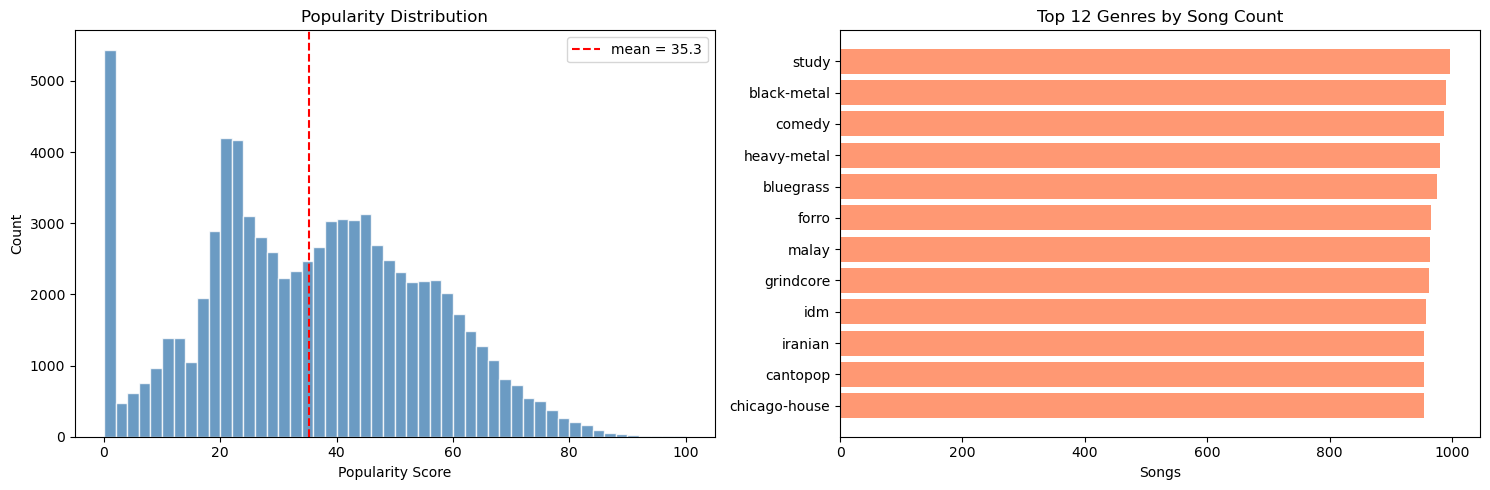

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# popularity distribution
axes[0].hist(df['popularity'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['popularity'].mean(), color='red', linestyle='--',
                label=f"mean = {df['popularity'].mean():.1f}")
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# top genres
top_genres = df['track_genre'].value_counts().head(12)
axes[1].barh(top_genres.index[::-1], top_genres.values[::-1], color='coral', alpha=0.8)
axes[1].set_title('Top 12 Genres by Song Count')
axes[1].set_xlabel('Songs')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Choosing Features for Mood Clustering

In [5]:
MOOD_FEATURES = [
    'valence',
    'energy',
    'danceability',
    'acousticness',
    'tempo',
    'loudness'
]

# quick summary of each feature
print(f"{'Feature':<15} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 42)
for feat in MOOD_FEATURES:
    print(f"{feat:<15} {df[feat].min():>8.2f} {df[feat].max():>8.2f} {df[feat].mean():>8.2f}")

Feature              Min      Max     Mean
------------------------------------------
valence             0.00     0.99     0.46
energy              0.00     1.00     0.63
danceability        0.00     0.98     0.56
acousticness        0.00     1.00     0.33
tempo               0.00   243.37   122.13
loudness          -49.53     4.53    -8.60


## 6. Feature Distributions

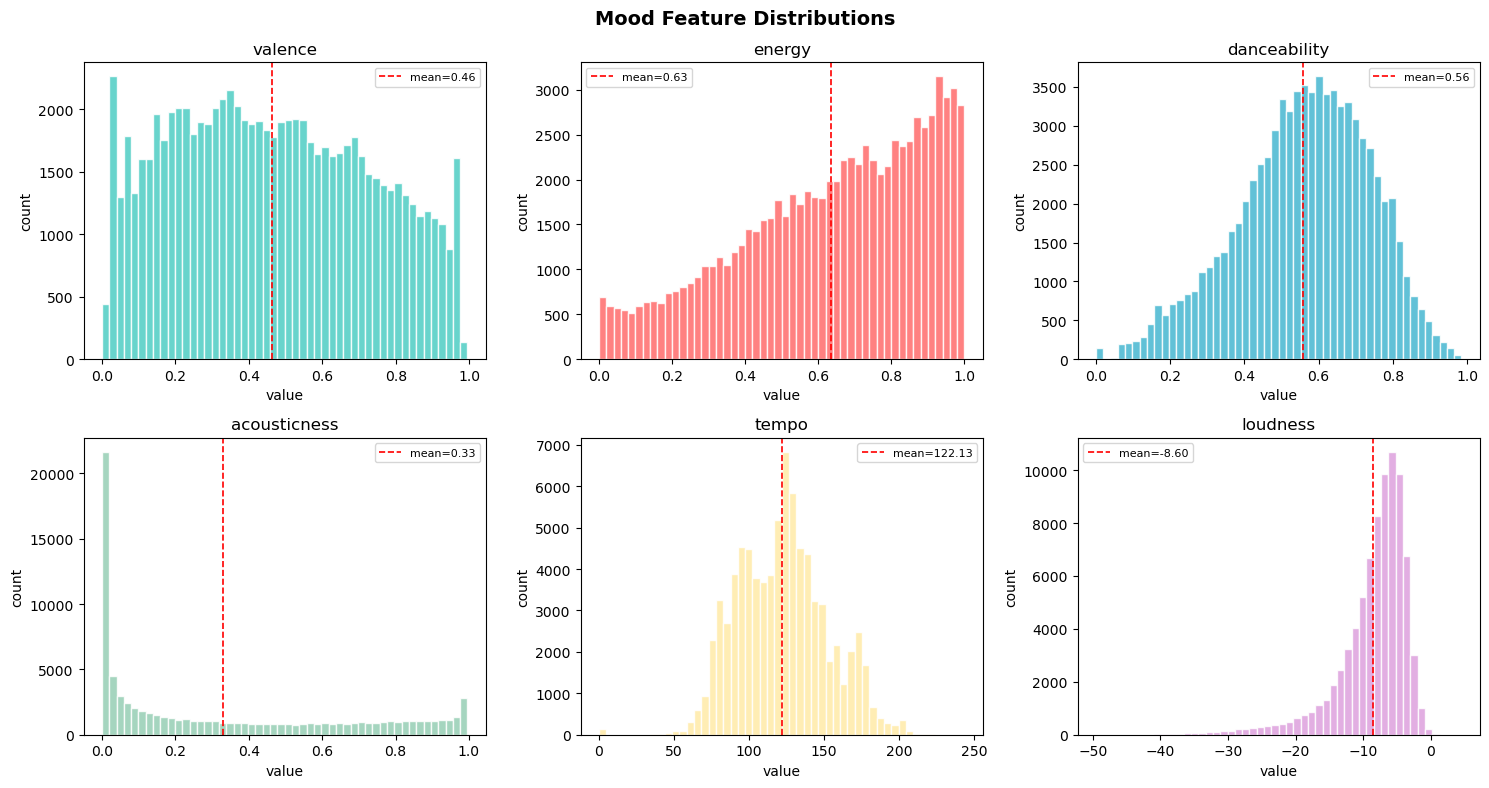

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Mood Feature Distributions', fontsize=14, fontweight='bold')

colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for i, (feat, color) in enumerate(zip(MOOD_FEATURES, colors)):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[feat], bins=50, color=color, edgecolor='white', alpha=0.85)
    axes[row, col].axvline(df[feat].mean(), color='red', linestyle='--', linewidth=1.2,
                           label=f"mean={df[feat].mean():.2f}")
    axes[row, col].set_title(feat)
    axes[row, col].set_xlabel('value')
    axes[row, col].set_ylabel('count')
    axes[row, col].legend(fontsize=8)

plt.tight_layout()
plt.savefig('mood_features_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Correlation Between Features

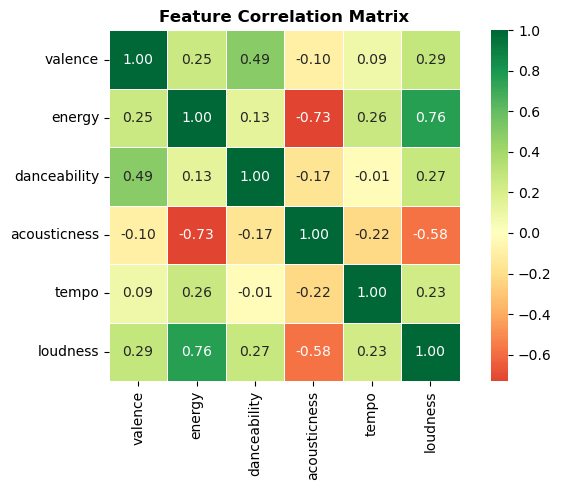

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[MOOD_FEATURES].corr(),
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Scaling the Features

In [8]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[MOOD_FEATURES])

print(f"Scaled shape: {features_scaled.shape}")
print(f"Mean after scaling: {features_scaled.mean():.4f}")
print(f"Std after scaling:  {features_scaled.std():.4f}")

Scaled shape: (81206, 6)
Mean after scaling: 0.0000
Std after scaling:  1.0000


## 9. Elbow Method — How Many Clusters?

k=2: inertia=335,206
k=3: inertia=274,998
k=4: inertia=240,670
k=5: inertia=217,888
k=6: inertia=203,770
k=7: inertia=190,381
k=8: inertia=179,109
k=9: inertia=169,368
k=10: inertia=162,797


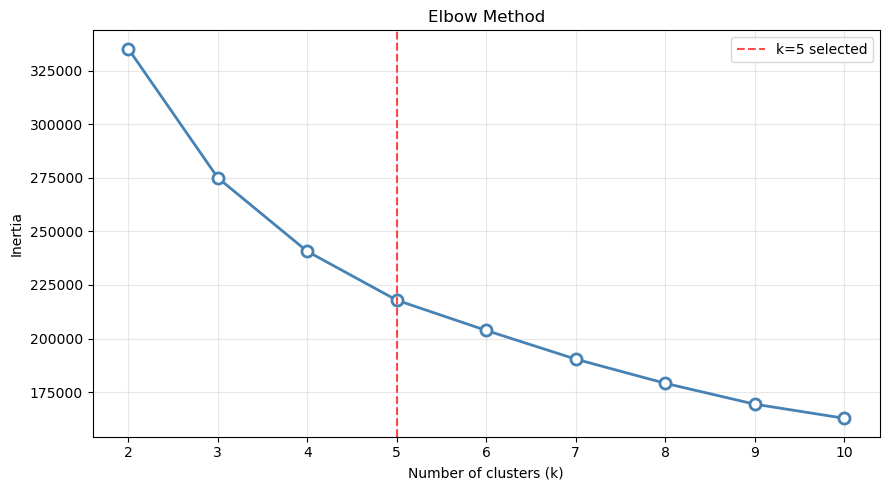

In [9]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:,.0f}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8,
         markerfacecolor='white', markeredgewidth=2)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5 selected')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Running K-Means (k=5)

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(features_scaled)

print("Songs per cluster:")
print(df['cluster'].value_counts().sort_index())

# average feature values per cluster to understand what each cluster represents
cluster_profile = df.groupby('cluster')[MOOD_FEATURES].mean().round(3)
print("Cluster profiles (average feature values):")
print(cluster_profile)

Songs per cluster:
cluster
0    18232
1     6693
2    14106
3    24279
4    17896
Name: count, dtype: int64
Cluster profiles (average feature values):
         valence  energy  danceability  acousticness    tempo  loudness
cluster                                                                
0          0.275   0.766         0.523         0.086  110.976    -6.689
1          0.158   0.163         0.307         0.862   99.791   -21.099
2          0.449   0.823         0.462         0.112  162.407    -5.497
3          0.726   0.730         0.709         0.220  118.437    -6.765
4          0.423   0.401         0.564         0.700  115.120   -10.800


## 11. Naming the Clusters

In [11]:
# Auto-detect which cluster is which mood by reading the actual feature values

def detect_mood_names(profile):
    """
    Assign mood names to cluster numbers based on audio feature profiles.
    This is robust — it reads the actual data rather than assuming fixed numbers.
    """
    assigned = {}
    remaining = list(profile.index)

    # Energetic = highest energy and highest tempo
    energetic = profile.loc[remaining, ['energy', 'tempo']].mean(axis=1).idxmax()
    assigned[energetic] = 'Energetic'
    remaining.remove(energetic)

    # Calm = lowest energy among remaining
    calm = profile.loc[remaining, 'energy'].idxmin()
    assigned[calm] = 'Calm'
    remaining.remove(calm)

    # Happy = highest valence among remaining
    happy = profile.loc[remaining, 'valence'].idxmax()
    assigned[happy] = 'Happy'
    remaining.remove(happy)

    # Sad = highest acousticness among remaining
    sad = profile.loc[remaining, 'acousticness'].idxmax()
    assigned[sad] = 'Sad'
    remaining.remove(sad)

    # Angry = whatever is left
    assigned[remaining[0]] = 'Angry'

    return assigned

MOOD_NAMES = detect_mood_names(cluster_profile)

print("Auto-detected mood mapping:")
for cluster_num, mood in sorted(MOOD_NAMES.items()):
    p = cluster_profile.loc[cluster_num]
    print(f"  Cluster {cluster_num} → {mood}")
    print(f"    valence={p['valence']:.3f}  energy={p['energy']:.3f}  "
          f"acousticness={p['acousticness']:.3f}  tempo={p['tempo']:.1f}")

df['mood'] = df['cluster'].map(MOOD_NAMES)

# define these here so they're available for all cells below
moods = ['Happy', 'Sad', 'Energetic', 'Calm', 'Angry']
mood_emojis = {'Happy':'😊', 'Sad':'😢', 'Energetic':'⚡', 'Calm':'😌', 'Angry':'😤'}
mood_colors  = {'Happy':'#FFD700', 'Sad':'#4169E1', 'Energetic':'#FF4500',
                'Calm':'#32CD32', 'Angry':'#DC143C'}

print()
print("Songs per mood:")
print(df['mood'].value_counts())

Auto-detected mood mapping:
  Cluster 0 → Angry
    valence=0.275  energy=0.766  acousticness=0.086  tempo=111.0
  Cluster 1 → Calm
    valence=0.158  energy=0.163  acousticness=0.862  tempo=99.8
  Cluster 2 → Energetic
    valence=0.449  energy=0.823  acousticness=0.112  tempo=162.4
  Cluster 3 → Happy
    valence=0.726  energy=0.730  acousticness=0.220  tempo=118.4
  Cluster 4 → Sad
    valence=0.423  energy=0.401  acousticness=0.700  tempo=115.1

Songs per mood:
mood
Happy        24279
Angry        18232
Sad          17896
Energetic    14106
Calm          6693
Name: count, dtype: int64


## 12. Checking Sample Songs Per Mood

In [12]:
# mood_emojis already defined above
for mood in ['Happy', 'Sad', 'Energetic', 'Calm', 'Angry']:
    sample = df[df['mood']==mood][['track_name','artists','valence','energy']].head(3)
    print(f"\n{mood_emojis[mood]} {mood}:")
    print(sample.to_string(index=False))


😊 Happy:
                           track_name                    artists  valence  energy
Quevedo: Bzrp Music Sessions, Vol. 52           Bizarrap;Quevedo    0.550   0.782
                           La Bachata              Manuel Turizo    0.850   0.679
                      Me Porto Bonito Bad Bunny;Chencho Corleone    0.425   0.712

😢 Sad:
   track_name   artists  valence  energy
Glimpse of Us      Joji    0.268   0.317
 Another Love Tom Odell    0.131   0.537
     PROVENZA   KAROL G    0.530   0.516

⚡ Energetic:
                   track_name         artists  valence  energy
                    As It Was    Harry Styles    0.662   0.731
Jimmy Cooks (feat. 21 Savage) Drake;21 Savage    0.366   0.673
              Blinding Lights      The Weeknd    0.334   0.730

😌 Calm:
                               track_name                                       artists  valence  energy
Clean White Noise - Loopable with no fade White Noise Baby Sleep;White Noise for Babies    0.000 0.00342
     

## 13. Most Popular Songs Per Mood

In [13]:
for mood in ['Happy', 'Sad', 'Energetic', 'Calm', 'Angry']:
    top = df[df['mood']==mood].nlargest(3, 'popularity')[
        ['track_name', 'artists', 'popularity']
    ]
    print(f"\n{mood_emojis[mood]} Top {mood} songs:")
    for _, row in top.iterrows():
        print(f"  {row['track_name'][:40]} - {row['artists'][:25]} (pop={row['popularity']})")


😊 Top Happy songs:
  Quevedo: Bzrp Music Sessions, Vol. 52 - Bizarrap;Quevedo (pop=99)
  La Bachata - Manuel Turizo (pop=98)
  Me Porto Bonito - Bad Bunny;Chencho Corleon (pop=97)

😢 Top Sad songs:
  Glimpse of Us - Joji (pop=94)
  Another Love - Tom Odell (pop=93)
  PROVENZA - KAROL G (pop=93)

⚡ Top Energetic songs:
  As It Was - Harry Styles (pop=95)
  Jimmy Cooks (feat. 21 Savage) - Drake;21 Savage (pop=91)
  Blinding Lights - The Weeknd (pop=91)

😌 Top Calm songs:
  Clean White Noise - Loopable with no fad - White Noise Baby Sleep;Wh (pop=85)
  rises the moon - Liana Flores (pop=81)
  Lights Are On - Tom Rosenthal (pop=81)

😤 Top Angry songs:
  Unholy (feat. Kim Petras) - Sam Smith;Kim Petras (pop=100)
  I'm Good (Blue) - David Guetta;Bebe Rexha (pop=98)
  Tití Me Preguntó - Bad Bunny (pop=97)


## 14. Mood Audio Profiles

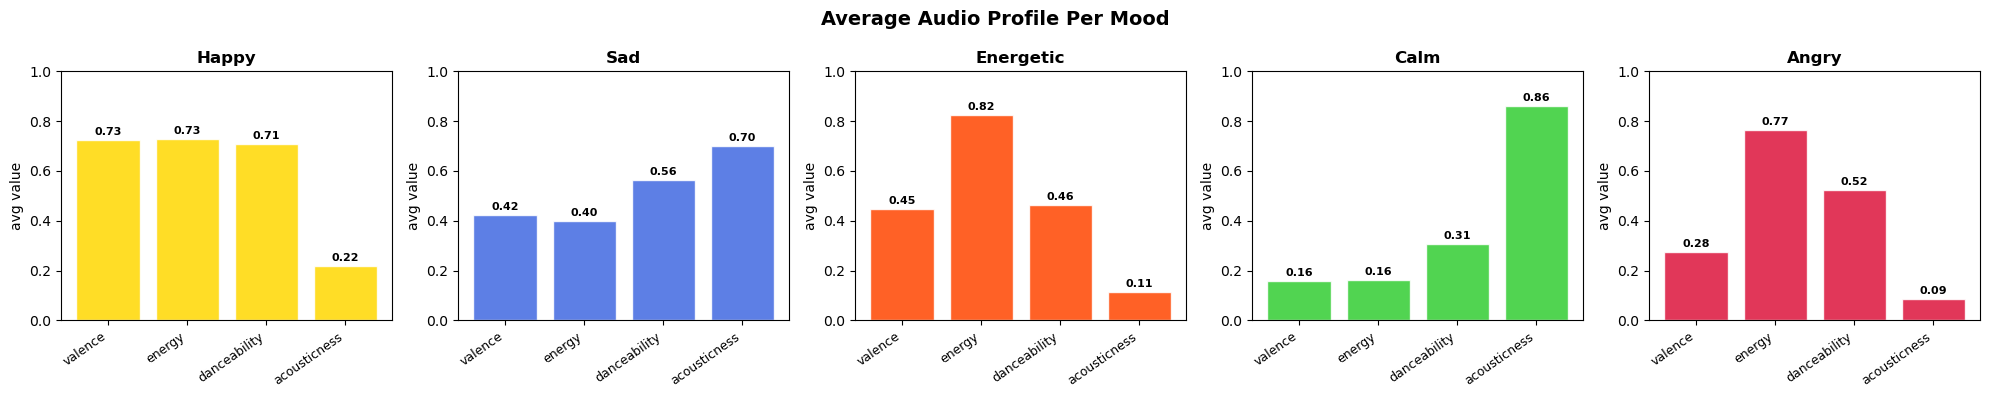

In [14]:
# mood_emojis, moods, mood_colors already defined above
features_to_plot = ['valence', 'energy', 'danceability', 'acousticness']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Average Audio Profile Per Mood', fontsize=14, fontweight='bold')

for i, mood in enumerate(moods):
    mood_data = df[df['mood']==mood][features_to_plot].mean()
    bars = axes[i].bar(features_to_plot, mood_data,
                       color=mood_colors[mood], alpha=0.85, edgecolor='white')
    axes[i].set_title(f"{mood}", fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(features_to_plot, rotation=35, ha='right', fontsize=9)
    axes[i].set_ylabel('avg value')
    for bar, val in zip(bars, mood_data):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                    f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('mood_profiles.png', dpi=120, bbox_inches='tight')
plt.show()

## 15. Visualising Clusters (PCA)

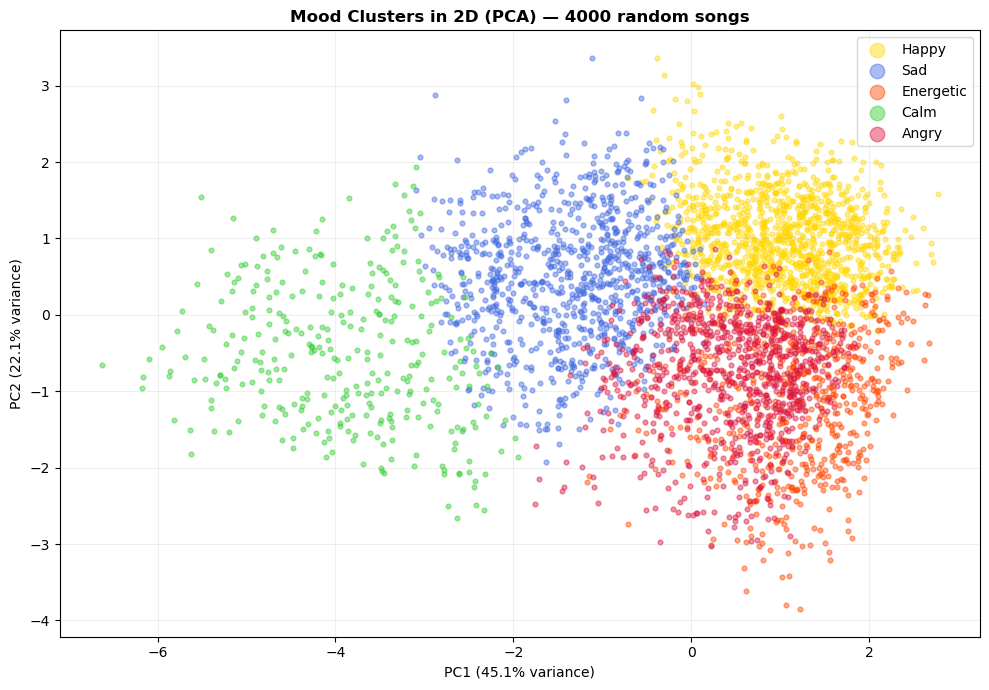

Variance explained by 2 components: 67.1%


In [15]:
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(features_scaled)

# use a random sample of 4000 points so the plot isn't too crowded
idx = np.random.choice(len(coords_2d), 4000, replace=False)

plt.figure(figsize=(10, 7))
for mood in moods:
    mask = df['mood'].iloc[idx] == mood
    plt.scatter(coords_2d[idx][mask, 0], coords_2d[idx][mask, 1],
                c=mood_colors[mood], label=f"{mood}",
                alpha=0.45, s=12)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Mood Clusters in 2D (PCA) — 4000 random songs', fontweight='bold')
plt.legend(markerscale=3)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.1f}%")

## 16. Saving Everything

In [16]:
os.makedirs('cache', exist_ok=True)

df.to_csv('cache/songs_with_moods.csv', index=False)
print(f"saved {len(df)} songs to cache/songs_with_moods.csv")

with open('cache/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("saved scaler to cache/scaler.pkl")

with open('cache/kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("saved kmeans model to cache/kmeans.pkl")

with open('cache/mood_names.pkl', 'wb') as f:
    pickle.dump(MOOD_NAMES, f)
print("saved mood names to cache/mood_names.pkl")

print("Files in cache/:")
for fname in sorted(os.listdir('cache')):
    kb = os.path.getsize('cache/' + fname) / 1024
    print(f"  {fname}: {kb:.1f} KB")

saved 81206 songs to cache/songs_with_moods.csv
saved scaler to cache/scaler.pkl
saved kmeans model to cache/kmeans.pkl
saved mood names to cache/mood_names.pkl
Files in cache/:
  kmeans.pkl: 318.0 KB
  mood_names.pkl: 0.2 KB
  scaler.pkl: 0.7 KB
  songs_with_moods.csv: 14296.6 KB
